In [1]:
import sys
import os
sys.path.append(r'C:\Users\emira\OneDrive\Desktop\main projem')
os.chdir(r'C:\Users\emira\OneDrive\Desktop\main projem')

import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from src.cialdini import CialdiniAnalyzer

X_train = np.load('data/processed/X_train.npy')
X_test = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_test = np.load('data/processed/y_test.npy')

with open('data/processed/feature_names.json') as f:
    feature_names = json.load(f)

cialdini = CialdiniAnalyzer()

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Feature sayısı: {len(feature_names)}')

Train: (24987, 64), Test: (25013, 64)
Feature sayısı: 64


In [2]:
# Feature gruplarını ayır
cialdini_cols = [i for i, f in enumerate(feature_names) if f.startswith('cld_')]
classic_cols = [i for i, f in enumerate(feature_names) if not f.startswith('cld_')]

print(f'Klasik feature sayısı: {len(classic_cols)}')
print(f'Cialdini feature sayısı: {len(cialdini_cols)}')
print(f'Cialdini features: {[feature_names[i] for i in cialdini_cols]}')

Klasik feature sayısı: 56
Cialdini feature sayısı: 8
Cialdini features: ['cld_authority', 'cld_scarcity', 'cld_fear', 'cld_reciprocity', 'cld_social_proof', 'cld_commitment', 'cld_total_score', 'cld_dominant_principle']


In [3]:
# 3 model eğit ve karşılaştır
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def train_and_evaluate(X_tr, X_te, y_tr, y_te, name):
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:,1]
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    print(f"{name}: ACC={acc:.4f}, F1={f1:.4f}, AUC={auc:.4f}")
    return clf, {"Model": name, "Accuracy": round(acc,4), "F1": round(f1,4), "AUC": round(auc,4)}

results = []

clf_classic, r1 = train_and_evaluate(X_train[:,classic_cols], X_test[:,classic_cols], y_train, y_test, "Sadece Klasik (56 feature)")
results.append(r1)

clf_cialdini, r2 = train_and_evaluate(X_train[:,cialdini_cols], X_test[:,cialdini_cols], y_train, y_test, "Sadece Cialdini (8 feature)")
results.append(r2)

clf_full, r3 = train_and_evaluate(X_train, X_test, y_train, y_test, "Klasik + Cialdini (64 feature)")
results.append(r3)

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

Sadece Klasik (56 feature): ACC=0.9336, F1=0.9340, AUC=0.9836
Sadece Cialdini (8 feature): ACC=0.5949, F1=0.3761, AUC=0.6185
Klasik + Cialdini (64 feature): ACC=0.9348, F1=0.9351, AUC=0.9838
                         Model  Accuracy     F1    AUC
    Sadece Klasik (56 feature)    0.9336 0.9340 0.9836
   Sadece Cialdini (8 feature)    0.5949 0.3761 0.6185
Klasik + Cialdini (64 feature)    0.9348 0.9351 0.9838


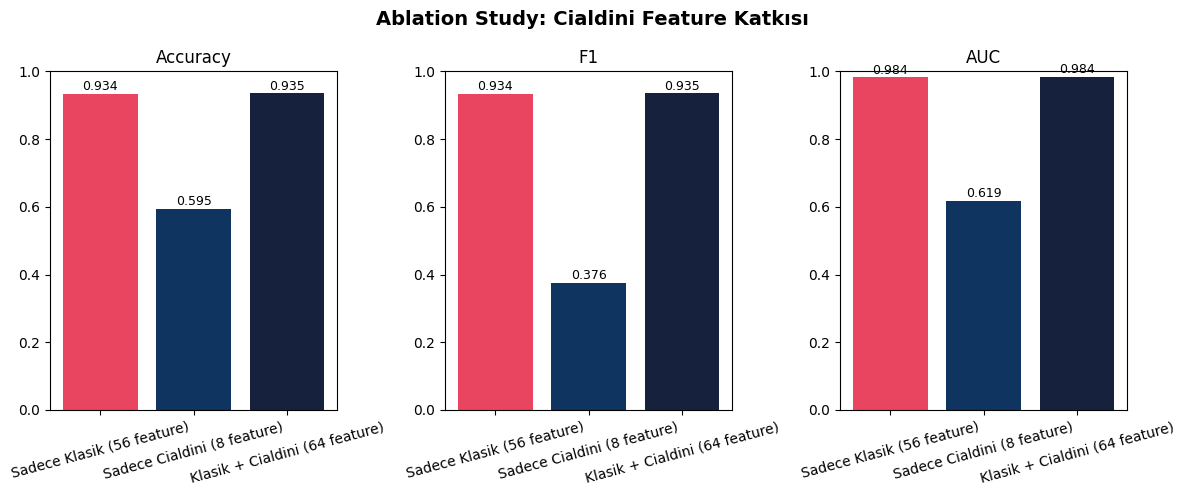

Kaydedildi!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
metrics = ['Accuracy', 'F1', 'AUC']
colors = ['#e94560', '#0f3460', '#16213e']

for idx, metric in enumerate(metrics):
    axes[idx].bar(df_results['Model'], df_results[metric], color=colors)
    axes[idx].set_title(metric)
    axes[idx].set_ylim(0, 1)
    axes[idx].tick_params(axis='x', rotation=15)
    for i, v in enumerate(df_results[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Ablation Study: Cialdini Feature Katkısı', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi!')

In [5]:
# Sadece Cialdini katkısıyla yakalanan phishing URL'leri bul
test_df = pd.read_csv('data/processed/raw_dataset.csv')
split_idx = int(len(test_df) * 0.5)
test_df = test_df.iloc[split_idx:].reset_index(drop=True)

pred_classic = clf_classic.predict(X_test[:,classic_cols])
pred_full = clf_full.predict(X_test)

only_cialdini = (pred_classic != y_test) & (pred_full == y_test) & (y_test == 1)

print(f"Sadece Cialdini katkısıyla yakalanan phishing: {only_cialdini.sum()} URL")
print(f"Test setinin %{only_cialdini.sum()/len(y_test)*100:.2f}'i")

caught_indices = np.where(only_cialdini)[0]
print("\nÖrnek URL'ler:")
for idx in caught_indices[:10]:
    if idx < len(test_df):
        url = test_df.iloc[idx]['url']
        cld = cialdini.explain(url)
        print(f"  URL: {url[:70]}")
        print(f"  Aktif ilkeler: {list(cld['active_principles'].keys())}")
        print()

Sadece Cialdini katkısıyla yakalanan phishing: 105 URL
Test setinin %0.42'i

Örnek URL'ler:
  URL: https://ez26.ez-web-hosting.com/~breezmed/wac/cgi/.hitaccess/.unknown/
  Aktif ilkeler: ['Otorite']

  URL: alanstrack.com/system/data/d03b508731b0b38a8de96abba4dff8fd/
  Aktif ilkeler: []

  URL: account.buscaunamascota.interactivos123.com/conexion/God/upgrade/newp/
  Aktif ilkeler: ['Bağlılık / Taahhüt']

  URL: http://ronblum.com.au/madoua4/personalindexsignon.php
  Aktif ilkeler: []

  URL: articles.philly.com/2011-04-03/sports/29377412_1_john-gaudreau-special
  Aktif ilkeler: ['Karşılıklılık / Ödül']

  URL: http://mitalex.ba/ovo/
  Aktif ilkeler: []

  URL: allmusic.com/album/the-blues-brothers-friends-live-from-house-of-blues
  Aktif ilkeler: []

  URL: https://www.ehow.com/how_7308831_trap-flying-insects-insecticide.html
  Aktif ilkeler: []

  URL: https://www.connors-vilardo.com/CJA.htm
  Aktif ilkeler: []

  URL: imagenation.us/wp-content/uploads/2012/Trulia/index.htm
  Aktif il

In [6]:
# Sadece aktif Cialdini ilkesi olan URL'leri göster
print("Cialdini ilkesi OLAN ve sadece tam model tarafından yakalanan URL'ler:\n")
count = 0
for idx in caught_indices:
    if idx < len(test_df):
        url = test_df.iloc[idx]['url']
        cld = cialdini.explain(url)
        if cld['active_principles']:  # Sadece aktif ilkesi olanlar
            print(f"  URL: {url[:70]}")
            print(f"  Aktif ilkeler: {list(cld['active_principles'].keys())}")
            print(f"  Eşleşen kelimeler: {cld['matched_words']}")
            print()
            count += 1
        if count >= 10:
            break

print(f"Toplam aktif ilkeli URL: {count}")

Cialdini ilkesi OLAN ve sadece tam model tarafından yakalanan URL'ler:

  URL: https://ez26.ez-web-hosting.com/~breezmed/wac/cgi/.hitaccess/.unknown/
  Aktif ilkeler: ['Otorite']
  Eşleşen kelimeler: {'authority': ['auth', 'secure', 'bank']}

  URL: account.buscaunamascota.interactivos123.com/conexion/God/upgrade/newp/
  Aktif ilkeler: ['Bağlılık / Taahhüt']
  Eşleşen kelimeler: {'commitment': ['account']}

  URL: articles.philly.com/2011-04-03/sports/29377412_1_john-gaudreau-special
  Aktif ilkeler: ['Karşılıklılık / Ödül']
  Eşleşen kelimeler: {'reciprocity': ['special']}

  URL: https://www.catshackreports.com/2011/09/sudden-harm-at-montreal-comicc
  Aktif ilkeler: ['Kıtlık / Aciliyet']
  Eşleşen kelimeler: {'scarcity': ['sudden']}

  URL: skvs.stedu.net/Images/index.htm?app=com-d3&amp;us.battle.net/login/en/
  Aktif ilkeler: ['Bağlılık / Taahhüt']
  Eşleşen kelimeler: {'commitment': ['login']}

  URL: www.people-choice.org/wp-includes/theme-compat/the/aol/costor/ubdet/in
  Aktif il